#Predicting House Prices with Linear Regression

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.shape

(545, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Dataset Overview

The housing dataset contains 545 records and 13 attributes related to residential properties.

The target variable is house price, while the remaining features describe property characteristics such as area, bedrooms, bathrooms, parking facilities, furnishing status, and other amenities.

In [8]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [9]:
df.duplicated().sum()

np.int64(0)

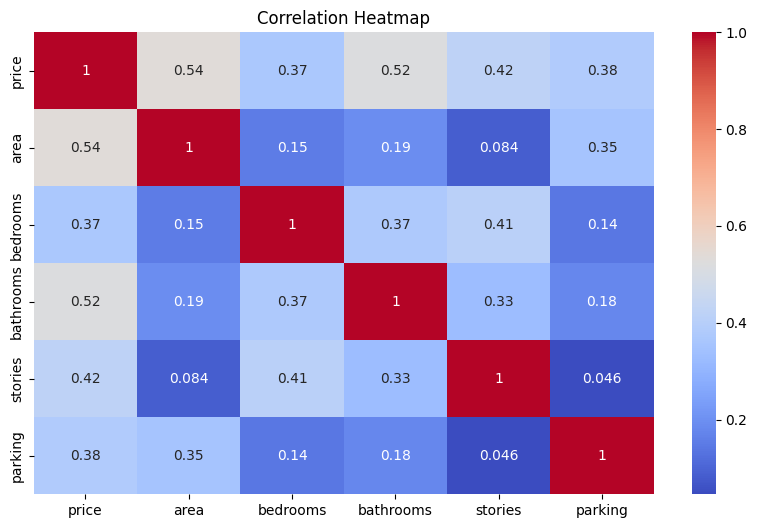

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

A correlation heatmap was generated to identify relationships between numerical features and house prices.

In [11]:
df = pd.get_dummies(df, drop_first=True)

In [12]:
X = df.drop("price", axis=1)

y = df["price"]

## Feature Selection

All housing attributes were selected as predictor variables, while house price was used as the target variable.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Training completed

A Linear Regression model was trained using housing features to predict house prices.

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1754318687330.6638
R2 Score: 0.6529242642153184


## Model Evaluation

Model performance was evaluated using Mean Squared Error (MSE) and R-squared (R²) score.

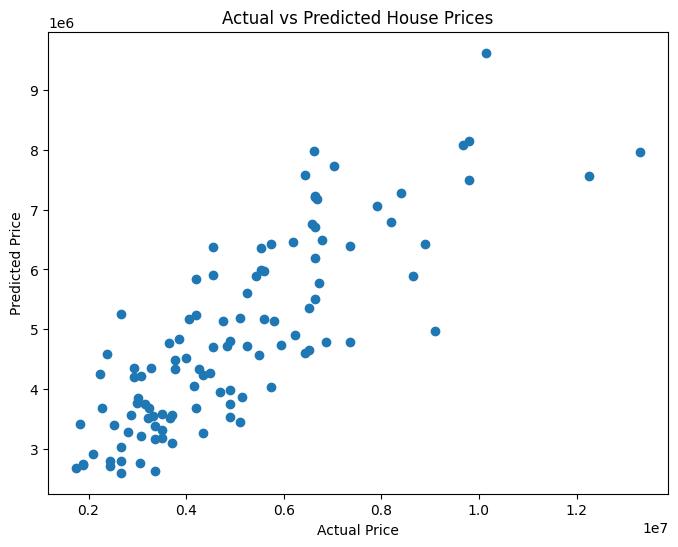

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

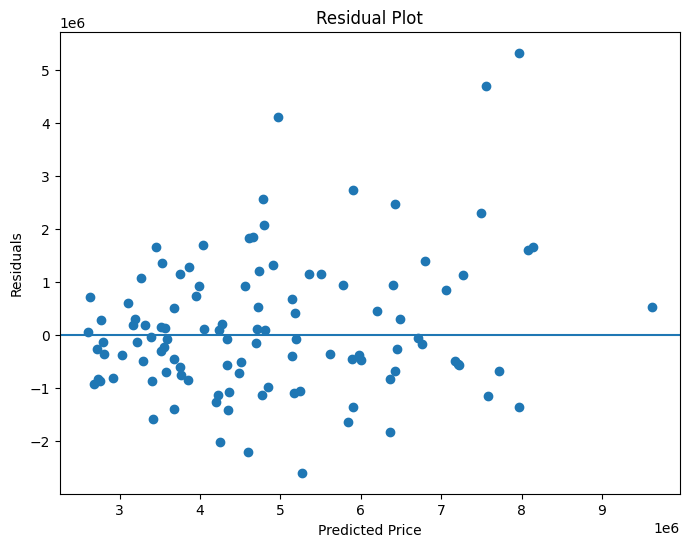

In [21]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Model is evaluated and we plotted a figure between actual and predicted prices.. and residual plot is also taken to assess prediction errors and evaluate model assumptions.

In [24]:
sample_house = X.iloc[[0]]

predicted_price = model.predict(sample_house)

print("Predicted House Price:", int(predicted_price[0]))
print("Actual Price    :", y.iloc[0])

Predicted House Price: 7968276
Actual Price    : 13300000


## Conclusion

A Linear Regression model was developed to predict house prices using various housing attributes such as area, bedrooms, bathrooms, parking facilities, furnishing status, and location preferences.

The analysis revealed that area, bathrooms, air conditioning, preferred area, and parking availability are among the most influential factors affecting house prices. The model achieved satisfactory predictive performance and demonstrated the practical application of machine learning in real-estate price estimation.

This project provided hands-on experience in data preprocessing, feature engineering, model training, evaluation, and interpretation of regression results.